In [4]:
!pip install -q transformers accelerate
!pip install -q torch torchvision
!pip install -q matplotlib pillow

print("✅ 설치 완료!")

✅ 설치 완료!


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (28.8 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/tru

/tmp/ipykernel_1023/811464798.py:34: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/811464798.py:34: UserWarning: Glyph 47352 (\N{HANGUL SYLLABLE RUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/811464798.py:34: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/811464798.py:34: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/811464798.py:34: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/811464798.py:34: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) 

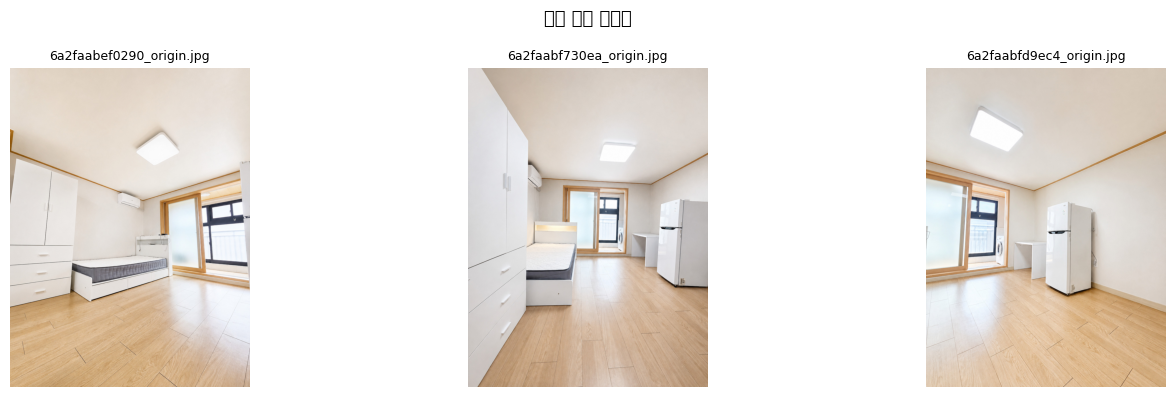

In [5]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'  # 한글 폰트
!apt-get install -q fonts-nanum && fc-cache -fv  # 한글 폰트 설치

base_path = "/content/02_Data/test1"

image_paths = sorted(
    glob.glob(f"{base_path}/*.jpg") +
    glob.glob(f"{base_path}/*.jpeg") +
    glob.glob(f"{base_path}/*.png") +
    glob.glob(f"{base_path}/*.JPG")
)

print(f"✅ 이미지 {len(image_paths)}장 발견")
for p in image_paths:
    img = Image.open(p)
    print(f"  └ {os.path.basename(p)} | {img.size[0]}x{img.size[1]} | {img.mode}")

# 미리보기
n = len(image_paths)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]

for ax, path in zip(axes, image_paths):
    ax.imshow(Image.open(path))
    ax.set_title(os.path.basename(path), fontsize=9)
    ax.axis('off')

plt.suptitle("원룸 원본 이미지", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
import torch
from transformers import pipeline

# GPU 확인
device = 0 if torch.cuda.is_available() else -1
print(f"디바이스: {'GPU ✅' if device == 0 else 'CPU ⚠️ (느릴 수 있어요)'}")

# 모델 로드 (Small = 빠름, Large = 정확)
# Small로 먼저 테스트하고 결과 보고 Large로 업그레이드 가능
depth_pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=device
)

print("✅ 모델 로드 완료!")

디바이스: GPU ✅


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

✅ 모델 로드 완료!


In [7]:
import numpy as np

depth_results = []
images_pil = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    result = depth_pipe(img)

    depth_map = np.array(result["depth"])
    depth_results.append(depth_map)
    images_pil.append(img)

    print(f"✅ {os.path.basename(path)}")
    print(f"   깊이맵 shape: {depth_map.shape}")
    print(f"   깊이값 범위: {depth_map.min():.1f} ~ {depth_map.max():.1f}")

print("\n🎉 전체 완료!")

✅ 6a2faabef0290_origin.jpg
   깊이맵 shape: (1448, 1086)
   깊이값 범위: 0.0 ~ 255.0
✅ 6a2faabf730ea_origin.jpg
   깊이맵 shape: (1448, 1086)
   깊이값 범위: 0.0 ~ 255.0
✅ 6a2faabfd9ec4_origin.jpg
   깊이맵 shape: (1448, 1086)
   깊이값 범위: 0.0 ~ 255.0

🎉 전체 완료!


/tmp/ipykernel_1023/1762057098.py:24: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1762057098.py:24: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1762057098.py:24: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1762057098.py:24: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1762057098.py:24: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1762057098.py:24: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1762057098.py:24: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layo

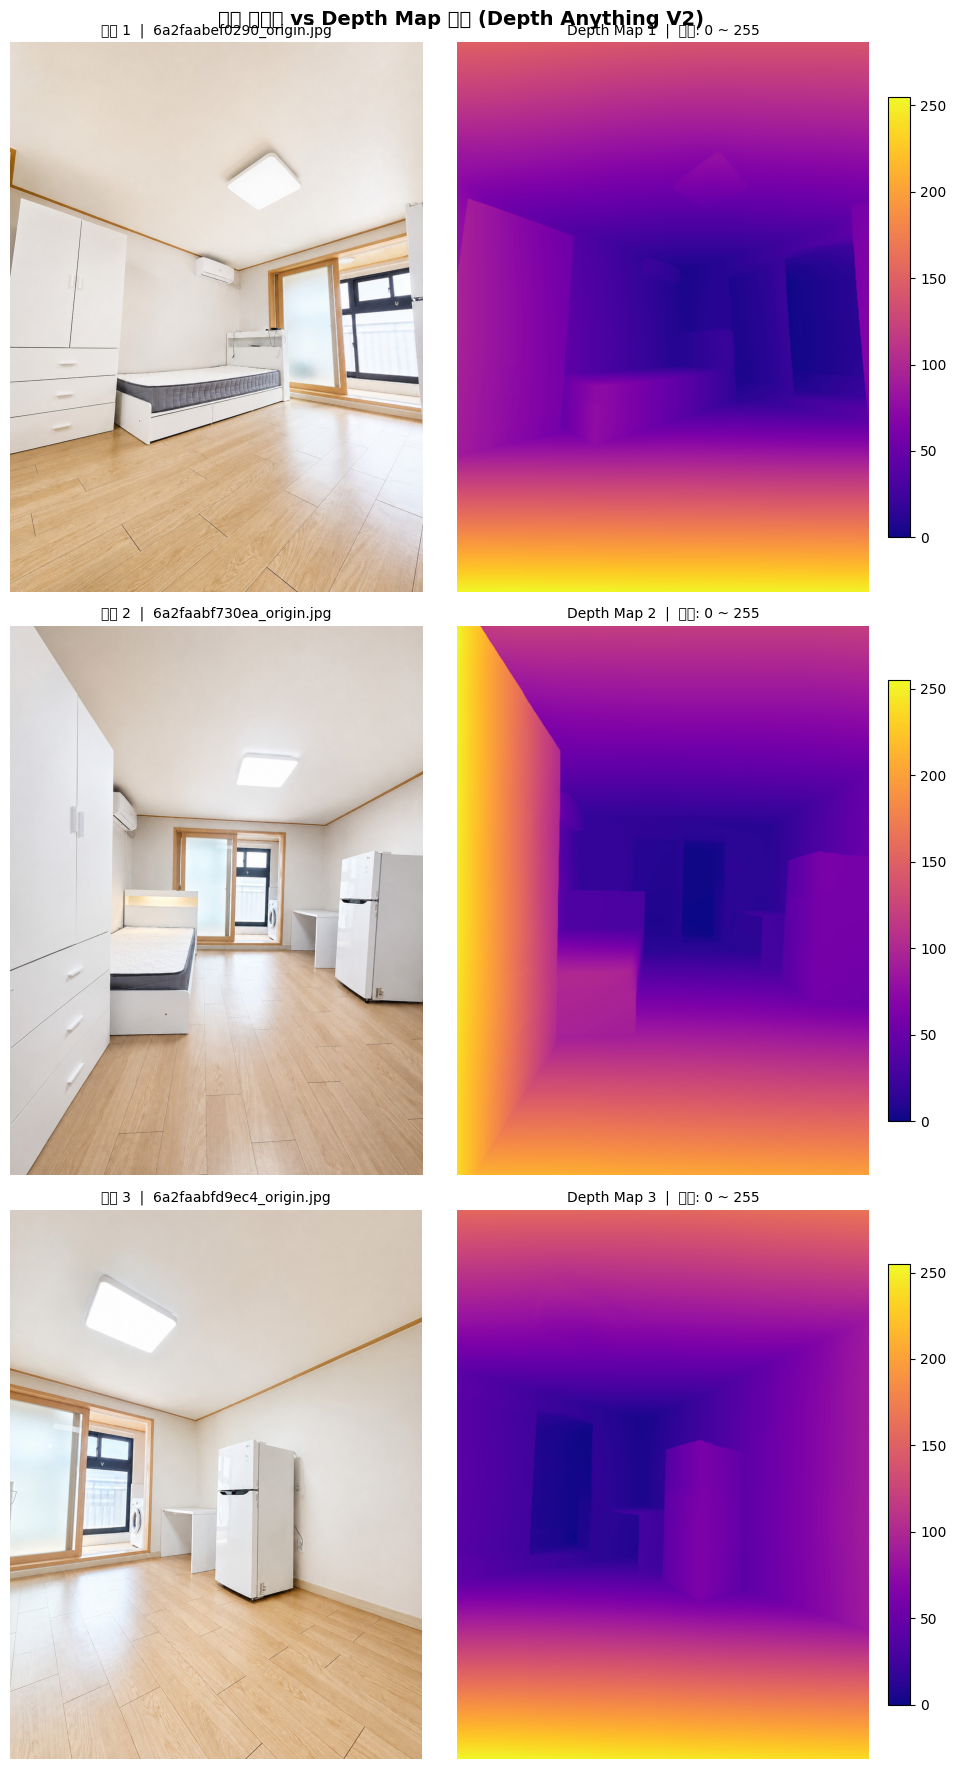

✅ 저장 완료: /content/02_Data/depth_comparison.png


In [8]:
n = len(images_pil)

# 세로형 이미지라 가로 배치 대신 이미지당 한 줄씩
fig, axes = plt.subplots(n, 2, figsize=(10, 6*n))

CMAP = 'plasma'

for i, (img, depth) in enumerate(zip(images_pil, depth_results)):

    # 왼쪽: 원본
    axes[i][0].imshow(img)
    axes[i][0].set_title(f"원본 {i+1}  |  {os.path.basename(image_paths[i])}",
                          fontsize=10)
    axes[i][0].axis('off')

    # 오른쪽: 깊이맵
    im = axes[i][1].imshow(depth, cmap=CMAP)
    axes[i][1].set_title(f"Depth Map {i+1}  |  범위: 0 ~ 255", fontsize=10)
    axes[i][1].axis('off')
    plt.colorbar(im, ax=axes[i][1], fraction=0.046, pad=0.04)

plt.suptitle("원본 이미지 vs Depth Map 비교 (Depth Anything V2)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/02_Data/depth_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장 완료: /content/02_Data/depth_comparison.png")

/tmp/ipykernel_1023/3705097659.py:29: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/3705097659.py:29: UserWarning: Glyph 48260 (\N{HANGUL SYLLABLE BEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/3705097659.py:29: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/3705097659.py:29: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/3705097659.py:29: UserWarning: Glyph 44618 (\N{HANGUL SYLLABLE GIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/3705097659.py:29: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/3705097659.py:29: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layo

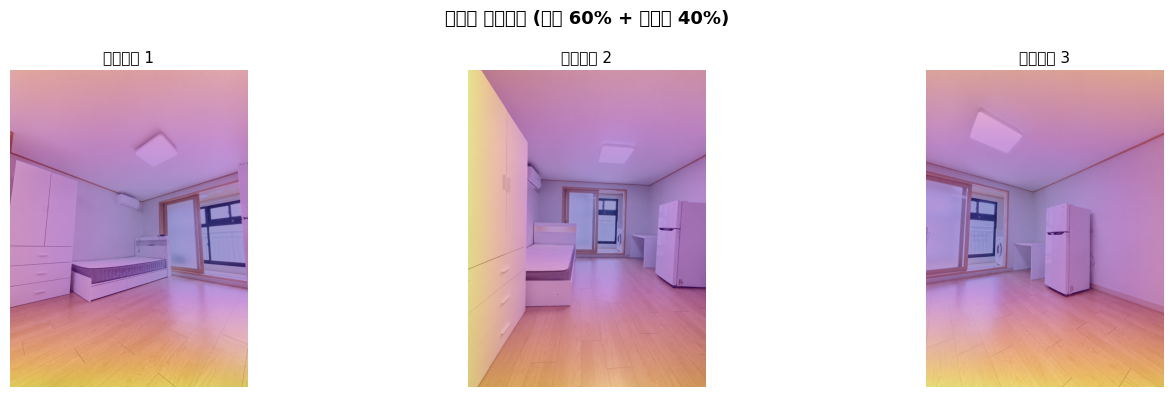

In [10]:
import matplotlib.cm as cm

fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]

for i, (img, depth) in enumerate(zip(images_pil, depth_results)):

    img_arr = np.array(img)

    # 깊이맵 정규화 → RGBA 컬러맵 적용
    depth_norm = (depth - depth.min()) / (depth.max() - depth.min())
    depth_colored = cm.plasma(depth_norm)  # RGBA

    # 원본 이미지 위에 반투명 오버레이
    depth_rgb = (depth_colored[:, :, :3] * 255).astype(np.uint8)
    depth_resized = np.array(
        Image.fromarray(depth_rgb).resize(
            (img_arr.shape[1], img_arr.shape[0])
        )
    )
    blended = (img_arr * 0.6 + depth_resized * 0.4).astype(np.uint8)

    axes[i].imshow(blended)
    axes[i].set_title(f"오버레이 {i+1}", fontsize=11)
    axes[i].axis('off')

plt.suptitle("깊이맵 오버레이 (원본 60% + 깊이맵 40%)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/02_Data/depth_overlay.png",
            dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1023/2998065782.py:21: UserWarning: Glyph 44618 (\N{HANGUL SYLLABLE GIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/2998065782.py:21: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/2998065782.py:21: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/2998065782.py:21: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/2998065782.py:21: UserWarning: Glyph 49472 (\N{HANGUL SYLLABLE SEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/2998065782.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/2998065782.py:21: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_

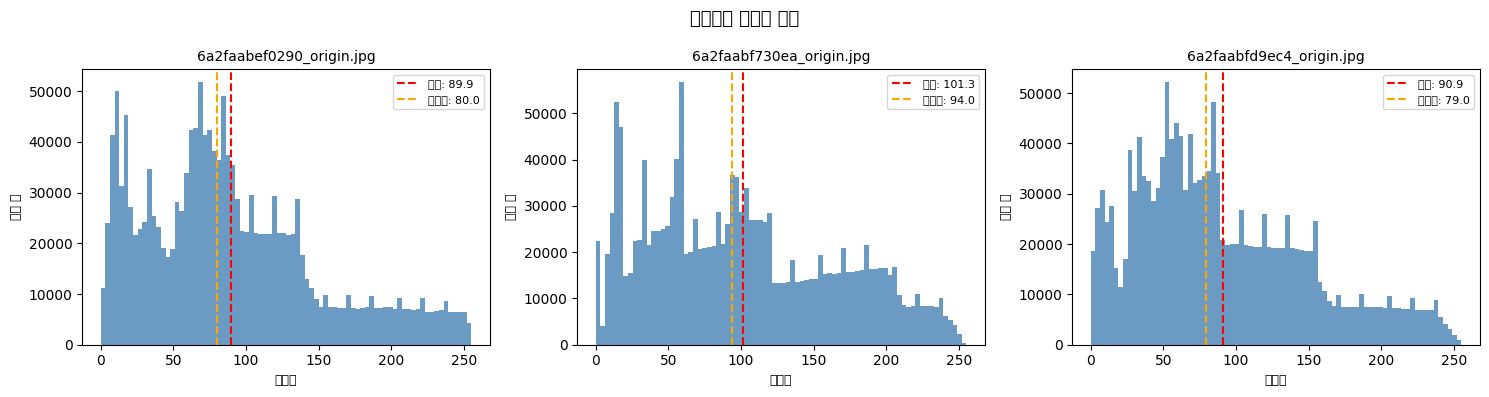


📊 깊이값 통계 요약
--------------------------------------------------

6a2faabef0290_origin.jpg
  평균:   89.86
  표준편차: 60.75
  최솟값: 0.00
  최댓값: 255.00

6a2faabf730ea_origin.jpg
  평균:   101.33
  표준편차: 64.84
  최솟값: 0.00
  최댓값: 255.00

6a2faabfd9ec4_origin.jpg
  평균:   90.86
  표준편차: 59.46
  최솟값: 0.00
  최댓값: 255.00


In [11]:
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]

for i, (depth, path) in enumerate(zip(depth_results, image_paths)):

    depth_flat = depth.flatten()

    axes[i].hist(depth_flat, bins=80, color='steelblue',
                 edgecolor='none', alpha=0.8)
    axes[i].axvline(depth_flat.mean(), color='red',
                    linestyle='--', linewidth=1.5, label=f'평균: {depth_flat.mean():.1f}')
    axes[i].axvline(np.median(depth_flat), color='orange',
                    linestyle='--', linewidth=1.5, label=f'중앙값: {np.median(depth_flat):.1f}')

    axes[i].set_title(f"{os.path.basename(path)}", fontsize=10)
    axes[i].set_xlabel("깊이값", fontsize=9)
    axes[i].set_ylabel("픽셀 수", fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle("이미지별 깊이값 분포", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/02_Data/depth_histogram.png",
            dpi=150, bbox_inches='tight')
plt.show()

# 수치 요약
print("\n📊 깊이값 통계 요약")
print("-" * 50)
for i, (depth, path) in enumerate(zip(depth_results, image_paths)):
    print(f"\n{os.path.basename(path)}")
    print(f"  평균:   {depth.mean():.2f}")
    print(f"  표준편차: {depth.std():.2f}")
    print(f"  최솟값: {depth.min():.2f}")
    print(f"  최댓값: {depth.max():.2f}")